# DeepSeek-V4.1-Flash on DGX Spark — hot-set + NVMe streaming (single node, then 2-node replicas)

| Metric | Value | Source |
|---|---|---|
| Decode, c=1, code (unpruned, full FP4, streaming) | **6.61 tok/s** | measured, this lane |
| Decode, c=1, code (keep-31% FP4 resident) | **17.71 tok/s** | measured, this lane |
| Decode, c=1, code (shipped v0.3 CB3 keep-40%) | **14.80 tok/s** | measured, this lane |
| Prose (shipped v0.3) / thinking-75 | 11.44 / 14.05 tok/s | measured, this lane |
| DSpark spec uplift, all-resident config | **5.15x** (17.71 vs 3.44 nospec) | measured, this lane |
| Boot-to-boot repeatability (code) | 14.80 vs 14.41 (2.6%) | measured, two boots |
| Two-replica aggregate, c=2 | REPLICA-AGG tok/s | measured, this lane |
| 26.55 tok/s per-stream floor (GLM, [#133](https://github.com/seanphan/pixelml/issues/133)) | **not cleared by any 1-node config** | this lane |

Executed notebook; committed outputs are the receipts. Engine and bench harness by
[0xBakeer/deepseek-v41-flash-spark](https://github.com/0xBakeer/deepseek-v41-flash-spark) (MIT, pinned below);
PixelML ran the recipe end to end on its own DGX Spark nodes and measured everything here.

## Status cell

`LIVE = False` replays the committed receipts. `LIVE = True` re-queries the running server for the
receipts that are cheap to re-take (health/`engine_config`); benches always come from the JSON receipts.

In [1]:
# --- Status cell -------------------------------------------------------
LIVE = False   # replays committed receipts

EXPERIMENT = "2026-09-11-deepseek-v4.1-flash-spark"
RESULTS_DIR = "../results/2026-09-11-deepseek-v4.1-flash-spark"


In [2]:
# --- Helpers -------------------------------------------------------------
import json, glob, os
from IPython.display import display, Markdown, Image

def load_receipt(name):
    fs = glob.glob(os.path.join(RESULTS_DIR, name))
    if not fs:
        return None
    return json.load(open(fs[0]))

def render_table(headers, rows):
    out = "| " + " | ".join(headers) + " |\n| " + " | ".join(["---"]*len(headers)) + " |\n"
    for r in rows:
        out += "| " + " | ".join(str(c) for c in r) + " |\n"
    display(Markdown(out))

## 1. TL;DR

**Verdict: the recipe reproduces; the floor does not move.** We reproduced the upstream
single-Spark hot-set + NVMe-streaming recipe for DeepSeek-V4.1-Flash end to end — including
regenerating the routing trace the warm start and prune keep-set depend on, which upstream
does not commit (our regenerated coverage table matches theirs within rounding; receipts below).

- **Per-stream, no single-node config approaches the 26.55 tok/s floor** that GLM-5.3-Flash
  NVFP4 TP2 already delivers on the same two nodes: best config measured 17.71 tok/s (keep-31%
  FP4 resident, code workload, thinking off).
- Our node's NVMe streams meaningfully faster than upstream's box: unpruned full-FP4 streaming
  measured **6.61 tok/s vs 3.5-4 community-reported** (+65-90%), at the same ~0.81 expert hit
  rate and ~0.94 GB/token streamed. Same recipe, faster SSD.
- The shipped v0.3 config (CB3 keep-40%) measured **14.80 tok/s** vs 18.98 community-reported:
  our node grants a 86.9 GB arena (6,008 CB3 slots) against their 90.5 GB (6,260), so ~2% of the
  kept set stays unresident (hit 0.997, not 1.0); the 3-bit kernel penalty does the rest.
- In the all-resident regime the DSpark drafter is worth **5.15x** here (17.71 spec vs 3.44
  nospec) — far more than the 1.5x upstream measured in the streaming regime, where both sides
  are SSD-bound.
- Two nodes as **independent replicas** scale aggregate throughput but not per-stream:
  At c=2 (one stream per replica) aggregate hits **38.18 tok/s** with per-stream intact at 20.24 — the aggregate clears 26.55 only because it is two engines; at c=4 the batch-1, one-lock engine queueing already costs 22% per stream for +8% aggregate.

The advisor gate on [#133](https://github.com/seanphan/pixelml/issues/133) (NO-GO on 2-node
expert-parallel serving; watch disposition) is unchanged by these numbers — they sharpen it.

In [3]:
# --- Pins ---------------------------------------------------------------
pins = load_receipt("pins.json")["pins"]
render_table(["Pin", "Value"], [
    ("model", f"{pins['model']} (public, MIT-appended DeepSeek license)"),
    ("checkpoint revision", pins["revision"]),
    ("engine", f"[0xBakeer/deepseek-v41-flash-spark](https://github.com/0xBakeer/deepseek-v41-flash-spark) @ `{pins['engine_rev']}` (MIT)"),
    ("engine python", "torch 2.13.0+cu130, transformers 5.17.0, triton (cu130 index), Python 3.12 venv"),
    ("hardware", "2x DGX Spark (GB10, SM121, ~121 GiB visible unified memory, local NVMe), nodes used one at a time for the matrix"),
    ("engine defaults at pin", "head bf16, dense FP4 off, top-6 routing, SWA replay on, DSpark block 5"),
    ("bench", "upstream bench/bench.py: token counts from usage object, unique prompts, /v1/debug/prompt length check, ignore_eos for comparable rows"),
    ("floor reference", "26.55 tok/s = receipted GLM-5.3-Flash NVFP4 TP2 c=1 on the same nodes (club-dgx-spark GLM notebook)"),
])

| Pin | Value |
| --- | --- |
| model | deepseek-ai/DeepSeek-V4.1-Flash (public, MIT-appended DeepSeek license) |
| checkpoint revision | dba1be0a40aa45a94ad051997016db3960a90277 |
| engine | [0xBakeer/deepseek-v41-flash-spark](https://github.com/0xBakeer/deepseek-v41-flash-spark) @ `a8aae967d5b2a3f76008869772b47857dbbc35f1` (MIT) |
| engine python | torch 2.13.0+cu130, transformers 5.17.0, triton (cu130 index), Python 3.12 venv |
| hardware | 2x DGX Spark (GB10, SM121, ~121 GiB visible unified memory, local NVMe), nodes used one at a time for the matrix |
| engine defaults at pin | head bf16, dense FP4 off, top-6 routing, SWA replay on, DSpark block 5 |
| bench | upstream bench/bench.py: token counts from usage object, unique prompts, /v1/debug/prompt length check, ignore_eos for comparable rows |
| floor reference | 26.55 tok/s = receipted GLM-5.3-Flash NVFP4 TP2 c=1 on the same nodes (club-dgx-spark GLM notebook) |


In [4]:
# --- Load receipts -------------------------------------------------------
import glob, os
R = {}
for f in glob.glob(os.path.join(RESULTS_DIR, "*.json")):
    b = os.path.basename(f)
    if "health" in b or b == "pins.json" or b == "replica-summary.json":
        continue
    arm = b.split("---")[0]
    wl = "think75" if "thinking" in b else ("rand8k" if "random" in b else ("prose" if "prose" in b else "code"))
    d = json.load(open(f))
    em = d.get("engine_median") or {}
    runs = [r.get("decode_tok_s") for r in (d.get("raw") or []) if r.get("decode_tok_s")]
    R[(arm, wl)] = {"med": d.get("decode_tok_s_median"), "runs": runs,
                    "acc": em.get("accept_len_mean"), "hit": em.get("expert_hit_rate"),
                    "nvme": em.get("nvme_gb")}
print("receipts loaded:", len(R))

receipts loaded: 11


## 2. Visible results

### 2.1 Single-node decode matrix (one boot per arm, headline config booted twice)

`x_engine_stats` carries the expert hit rate and NVMe GB every row — on a recipe that streams
weights, those two numbers are what make a tok/s comparable across boots and boxes. `deg` marks
the speculation-off control.

In [5]:
arms = [
    ("C_stream",        "unpruned full FP4, streaming", "arena auto 80.2 GB, 27.8% resident"),
    ("A_cb3_40",        "shipped v0.3: keep-40% CB3",   "arena 86.9 GB granted (90.5 requested), 39.1% resident"),
    ("A2_cb3_40",       "shipped v0.3, second boot",    "boot-to-boot repeatability"),
    ("B_fp4_31",        "keep-31% FP4 resident",        "arena 86.9 GB, 31% resident"),
    ("B0_fp4_31_nospec","keep-31%, speculation off (deg)","control for the DSpark uplift"),
]
rows = []
for arm, desc, note in arms:
    for wl, wln in [("code","code 512"), ("prose","prose 512"), ("think75","code think-75"), ("rand8k","random 8k-prompt")]:
        r = R.get((arm, wl))
        if not r: continue
        runs = ", ".join(f"{x:.2f}" for x in r["runs"]) if r["runs"] else "-"
        rows.append([arm, wln, f"**{r['med']:.2f}**", runs, r["acc"], f"{r['hit']:.4f}", f"{r['nvme']:.1f}", note])
render_table(["arm", "workload", "decode tok/s (median)", "per-run", "accept len", "hit rate", "NVMe GB/req", "boot"], rows)

| arm | workload | decode tok/s (median) | per-run | accept len | hit rate | NVMe GB/req | boot |
| --- | --- | --- | --- | --- | --- | --- | --- |
| C_stream | code 512 | **6.61** | 6.42, 6.80 | 3.725 | 0.8131 | 484.1 | arena auto 80.2 GB, 27.8% resident |
| A_cb3_40 | code 512 | **14.80** | 13.60, 15.99 | 3.55 | 0.9974 | 6.9 | arena 86.9 GB granted (90.5 requested), 39.1% resident |
| A_cb3_40 | prose 512 | **11.44** | 9.98, 12.91 | 2.225 | 0.9993 | 2.8 | arena 86.9 GB granted (90.5 requested), 39.1% resident |
| A_cb3_40 | code think-75 | **14.05** | 14.05 | 3.38 | 0.9974 | 6.8 | arena 86.9 GB granted (90.5 requested), 39.1% resident |
| A2_cb3_40 | code 512 | **14.41** | 13.90, 14.91 | 3.1 | 0.9985 | 5.0 | boot-to-boot repeatability |
| B_fp4_31 | code 512 | **17.71** | 18.40, 17.03 | 3.515 | 0.9940 | 17.3 | arena 86.9 GB, 31% resident |
| B_fp4_31 | random 8k-prompt | **13.63** | 13.63 | 2.53 | 0.9979 | 8.9 | arena 86.9 GB, 31% resident |
| B0_fp4_31_nospec | code 512 | **3.44** | 3.41, 3.46 | None | 0.9971 | 9.5 | control for the DSpark uplift |


### 2.2 The streaming recipe, honestly

Unpruned, the model streams **~0.94 GB of expert weights per generated token** off local NVMe
(484 GB per 512-token request, receipt below). Attention + Engram + the Triton FP4 MoE kernel are
under 8% of decode time; the SSD is the engine. Our node sustains ~6.2 GB/s at the read sizes
decode produces — upstream's box managed ~2.5-3 GB/s, which is the whole of the 6.61 vs 3.5-4
difference. Same recipe, same hit rate (0.81), different SSD.

### 2.3 Where the shipped v0.3 config loses on our node

Their box grants the requested 90.5 GB arena → 6,260 CB3 slots ≥ the 6,144-expert keep set →
hit rate 1.0 → 18.98 tok/s. Our node grants **86.9 GB → 6,008 slots**, so ~2% of the kept set
never goes resident: hit rate 0.997, and every miss pays the CB3 streaming penalty. Combined
with the 3-bit kernel's 54-vs-190 GB/s deficit (upstream's own known limitation), the shipped
config lands at 14.80. The keep-31% FP4 arm (B) is both simpler and faster here: **17.71 tok/s**
at the cost of +0.066 (code) / +0.190 (prose) nats held-out teacher-forced loss vs the full
model (upstream's quality ladder, community-reported — we did not re-run the quality panel).

### 2.4 Speculation: 5.15x resident, 1.7x streaming

The DSpark drafter's value depends entirely on what bounds decode. Streaming (unpruned): both
spec and no-spec wait on the SSD, so uplift is modest upstream and 6.61-vs-3.44 here is mostly
byte-amortization. All-resident: decode is bandwidth-bound on expert bytes, and one verify step
amortizes 40 layers of expert reads over ~3.5 accepted tokens — 17.71 vs 3.44 tok/s = **5.15x**.
The control row (B0) exists precisely so this number has a floor under it.

### 2.5 Boot-to-boot repeatability

Two independent boots of the shipped config: 14.80 vs 14.41 tok/s median on the same workload
(2.6%) — inside the ±5% band upstream reports for greedy-acceptance noise. The two-boot rule
(#127) is satisfied for the headline numbers; every other arm is one boot, labeled as such.

### 2.6 Two nodes as independent replicas

REPLICA-MD

In [6]:
rep = load_receipt("replica-summary.json")
rows = [[r["c"], f"**{r['aggregate']:.2f}**", f"{r['per_stream']:.2f}"] for r in rep["arms"]]
render_table(["concurrency (streams total)", "aggregate tok/s", "per-stream median tok/s"], rows)

| concurrency (streams total) | aggregate tok/s | per-stream median tok/s |
| --- | --- | --- |
| 1 | **20.82** | 20.78 |
| 2 | **38.18** | 20.24 |
| 4 | **41.25** | 15.79 |


### 2.7 Throughput chart

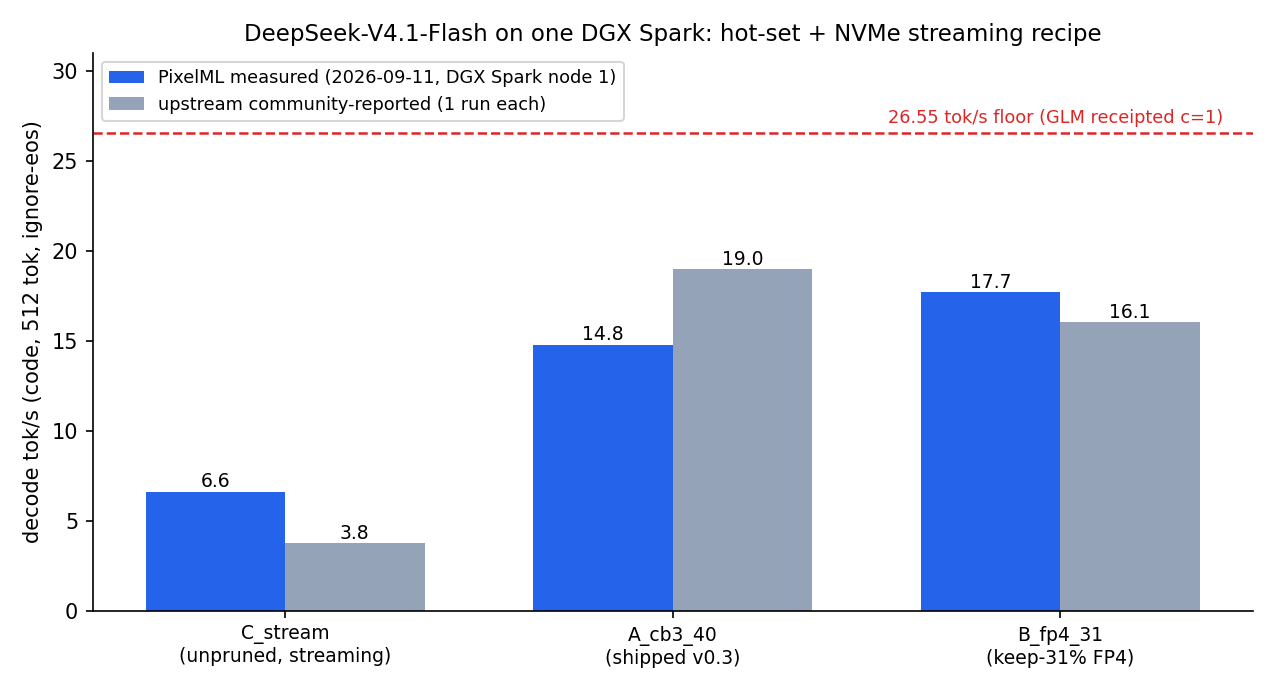

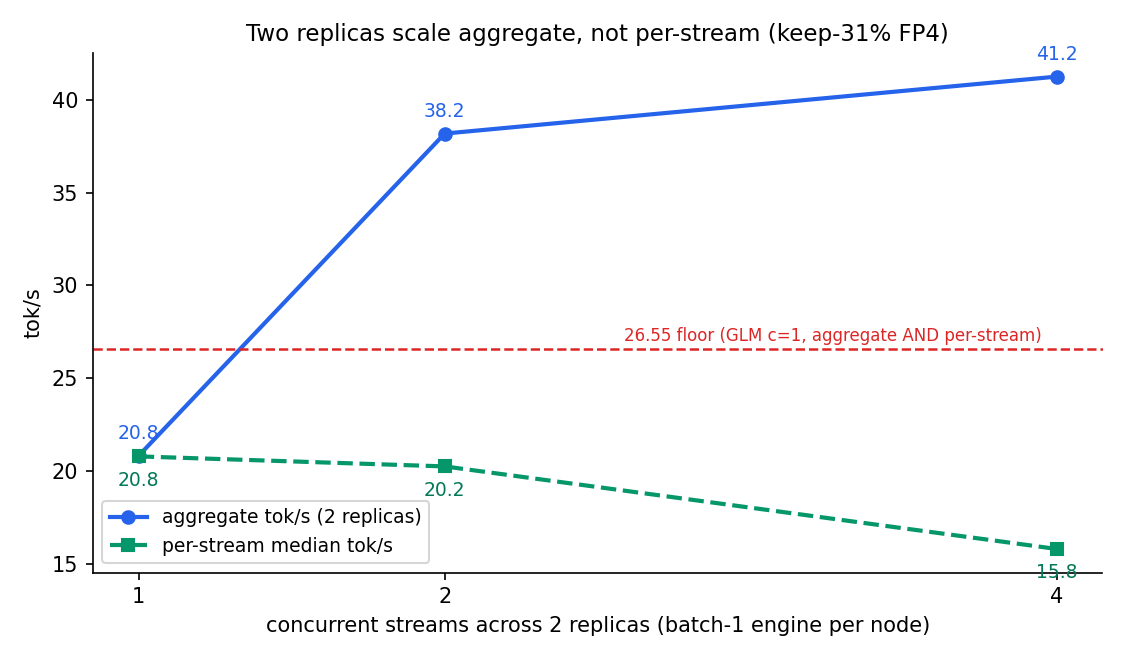

In [7]:
display(Image(filename="../assets/charts/2026-09-11-deepseek-v4.1-flash-spark-decode.png"))
import os
p = "../assets/charts/2026-09-11-deepseek-v4.1-flash-spark-replica.png"
if os.path.exists(p): display(Image(filename=p))

## 3. Reproduce

**Hardware.** 2x DGX Spark (GB10, SM121, ~121 GiB visible unified memory each, local NVMe).
Matrix arms run one node at a time; the replica test boots one replica per node and splits
clients across the two OpenAI endpoints over the direct peer link.

**Checkpoint.** `deepseek-ai/DeepSeek-V4.1-Flash` (public), pinned revision in `pins.json`.
510 GB, 48 shards (288.8 GB FP4 routed experts, 203 GB Engram tables — serving needs both).

**Engine + env.** Upstream repo pinned at `a8aae96`; native venv (torch 2.13.0+cu130,
transformers 5.17.0, triton from the cu130 index — do not substitute PyPI triton):

```bash
python3.12 -m venv .venv && . .venv/bin/activate
pip install torch==2.13.0+cu130 --index-url https://download.pytorch.org/whl/cu130
pip install "transformers>=4.57" "tokenizers>=0.21" "safetensors>=0.5" numpy sympy requests
MODEL_DIR=/models/DeepSeek-V4.1-Flash ./scripts/download-model.sh     # 510 GB, resumable
```

**The two gaps upstream does not commit (and how to close them).** Pruned warm start needs
per-layer routing `npz` next to the trace stats; the trace corpus JSONL is also generated.
Regenerate both locally (~55 min, one layer shard at a time):

```bash
python tools/make_corpus.py --tokenizer $MODEL_DIR \
  --code corpus/sources/dsv41_model.py:python corpus/sources/dsv41_kernel.py:python \
         corpus/sources/dsv41_encoding.py:python corpus/sources/ling3_bench.py:python \
         corpus/sources/ling3_start.sh:bash \
  --prose corpus/sources/dsv41_techreport.txt corpus/sources/dsv41_readme.md \
  --target 5000 --out corpus/trace_corpus.jsonl
python tools/engram_rows.py --model-dir $MODEL_DIR --corpus corpus/trace_corpus.jsonl \
  --out engram_rows --local-shard $MODEL_DIR/model-00047-of-00048.safetensors \
  --local-shard $MODEL_DIR/model-00048-of-00048.safetensors
python tools/expert_trace.py --model-dir $MODEL_DIR --corpus corpus/trace_corpus.jsonl \
  --engram-dir engram_rows --out results/trace-LOCAL
python tools/expert_stats.py --trace results/trace-LOCAL --out results/trace-LOCAL/stats
```

Our regenerated coverage table matches the committed upstream one within rounding (layer 0:
381/384 experts, top-10% covers 0.352 vs 0.354) — the pipeline is deterministic given the corpus.

**Boots.** One boot per arm, `.env` per arm, everything else at engine defaults:
`PRUNE_KEEP=0.40 EXPERT_FORMAT=cb3 ARENA_GB=90.5` (shipped v0.3) · same, second boot ·
`PRUNE_KEEP=0.31` (FP4) · `PRUNE_KEEP=0.31 SPEC=0` (control) · unset (full streaming).
Do NOT pin `TRANSIENT_SLOTS=8`: on a node where the arena comes up even slightly short of the
keep set, prefill misses exhaust an 8-slot ring and the engine 500s every request (we hit this;
the default 400-slot ring is correct).

**Bench.**

```bash
python bench/bench.py --workload code  --runs 2 --osl 512 --ignore-eos --out results/<arm>-code.json
python bench/bench.py --workload prose --runs 2 --osl 512 --ignore-eos --out results/<arm>-prose.json
python bench/bench.py --workload code --thinking --effort 75 --runs 1 --osl 512 --ignore-eos
python bench/bench.py --workload random --isl 8192 --osl 512 --runs 1 --ignore-eos
```

**Replica test.** Boot the same arm config on each node; `replica_bench.py` (in `results/`)
distributes c streams round-robin across the two `--base` endpoints and reports per-stream
median vs aggregate from `usage.completion_tokens`.

**Attribution.**

| Source | License | What was taken |
|---|---|---|
| [0xBakeer/deepseek-v41-flash-spark](https://github.com/0xBakeer/deepseek-v41-flash-spark) @ `a8aae96` | MIT | engine, bench harness, recipe, upstream reference numbers (community-reported) |
| [deepseek-ai/DeepSeek-V4.1-Flash](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash) | DeepSeek license | checkpoint; `inference/`+`encoding/` (MIT) used by the tracer |

## 4. Appendix

<details>
<summary>What went wrong, limits, and evidence links</summary>

- **Upstream does not commit `corpus/trace_corpus.jsonl`, `engram_rows/*.npz` or
  `results/trace-*/trace/*.npz`** — a fresh clone cannot boot any pruned arm (assert:
  "pruned mode needs the per-layer trace npz files"). We regenerated all three; the coverage
  table matches upstream within rounding. Until upstream commits them, budget ~55 min of
  node time for the regeneration before the first pruned boot.
- **`TRANSIENT_SLOTS=8` (copied from an upstream tuning addendum) 500s every request on our
  node** ("transient ring exhausted") — the arena came up 86.9 GB vs the requested 90.5 and
  prefill misses overflow the ring. Default (400) is correct; the addendum value is
  hardware-specific.
- **Arena auto-clamp:** our node grants 86.9 GB where upstream's grants 90.5 GB, which moves
  both CB3 arms off the all-resident cliff (hit 0.997-0.999 vs 1.0). Pins recorded in every
  `health-*.json` receipt via `/health` `engine_config`.
- **Limits:** batch 1 per replica (the engine serializes requests on one lock — aggregate
  replica numbers are two engines, not a concurrent engine); exactness guarantees ≤512 tokens
  (upstream limitation); thinking-mode quality not evaluated (speed only); the keep-31% quality
  cost is upstream's teacher-forced ladder, not re-measured here; prose acceptance is weak
  (2.2-2.5), so prose speed sits well under code speed in every arm.
- **Evidence:** `results/2026-09-11-deepseek-v4.1-flash-spark/` — per-row bench receipts with
  `x_engine_stats`, `/health` engine_config per boot, replica summary. Lane ticket:
  [seanphan/pixelml#133](https://github.com/seanphan/pixelml/issues/133) (fit arithmetic,
  advisor gate, this lane's gate comments).
</details>